In [1]:
!pip install tensorflow-text

     ---------------------------------------- 5.0/5.0 MB 10.7 MB/s eta 0:00:00
     ---------------------------------------- 100.6/100.6 kB ? eta 0:00:00
     ------------------------------------ 455.9/455.9 MB 359.0 kB/s eta 0:00:00
     ---------------------------------------- 5.9/5.9 MB 8.2 MB/s eta 0:00:00
     -------------------------------------- 438.7/438.7 kB 5.4 MB/s eta 0:00:00



[notice] A new release of pip available: 22.3.1 -> 23.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


     ---------------------------------------- 1.7/1.7 MB 9.0 MB/s eta 0:00:00
  Using cached opt_einsum-3.3.0-py3-none-any.whl (65 kB)
     ---------------------------------------- 1.5/1.5 MB 15.7 MB/s eta 0:00:00
     ---------------------------------------- 24.4/24.4 MB 4.4 MB/s eta 0:00:00
     ---------------------------------------- 42.6/42.6 kB 1.0 MB/s eta 0:00:00
     -------------------------------------- 233.6/233.6 kB 7.2 MB/s eta 0:00:00
  Attempting uninstall: keras
    Found existing installation: keras 2.11.0
    Uninstalling keras-2.11.0:
      Successfully uninstalled keras-2.11.0
  Attempting uninstall: tensorflow-estimator
    Found existing installation: tensorflow-estimator 2.11.0
    Uninstalling tensorflow-estimator-2.11.0:
      Successfully uninstalled tensorflow-estimator-2.11.0


In [2]:
import tensorflow as tf
import tensorflow_text as text

c:\users\lokesh\appdata\local\programs\python\python39\lib\site-packages\scipy\__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


In [4]:
docs = tf.constant([u'Everything not saved will be lost.'.encode('UTF-16-BE'), u'Sad☹'.encode('UTF-16-BE')])
utf8_docs = tf.strings.unicode_transcode(docs, input_encoding='UTF-16-BE', output_encoding='UTF-8')

In [5]:
tokenizer = text.WhitespaceTokenizer()
tokens = tokenizer.tokenize(['everything not saved will be lost.', u'Sad☹'.encode('UTF-8')])
print(tokens.to_list())

[[b'everything', b'not', b'saved', b'will', b'be', b'lost.'], [b'Sad\xe2\x98\xb9']]


In [6]:
tokenizer = text.UnicodeScriptTokenizer()
tokens = tokenizer.tokenize(['everything not saved will be lost.', u'Sad☹'.encode('UTF-8')])
print(tokens.to_list())

[[b'everything', b'not', b'saved', b'will', b'be', b'lost', b'.'], [b'Sad', b'\xe2\x98\xb9']]


In [7]:
tokens = tf.strings.unicode_split([u"仅今年前".encode('UTF-8')], 'UTF-8')
print(tokens.to_list())

[[b'\xe4\xbb\x85', b'\xe4\xbb\x8a', b'\xe5\xb9\xb4', b'\xe5\x89\x8d']]


In [8]:
tokenizer = text.UnicodeScriptTokenizer()
(tokens, offset_starts, offset_limits) = tokenizer.tokenize_with_offsets(['everything not saved will be lost.', u'Sad☹'.encode('UTF-8')])
print(tokens.to_list())
print(offset_starts.to_list())
print(offset_limits.to_list())

[[b'everything', b'not', b'saved', b'will', b'be', b'lost', b'.'], [b'Sad', b'\xe2\x98\xb9']]
[[0, 11, 15, 21, 26, 29, 33], [0, 3]]
[[10, 14, 20, 25, 28, 33, 34], [3, 6]]


In [9]:
docs = tf.data.Dataset.from_tensor_slices([['Never tell me the odds.'], ["It's a trap!"]])
tokenizer = text.WhitespaceTokenizer()
tokenized_docs = docs.map(lambda x: tokenizer.tokenize(x))
iterator = iter(tokenized_docs)
print(next(iterator).to_list())
print(next(iterator).to_list())

[[b'Never', b'tell', b'me', b'the', b'odds.']]
[[b"It's", b'a', b'trap!']]


In [10]:
tokenizer = text.WhitespaceTokenizer()
tokens = tokenizer.tokenize(['Everything not saved will be lost.', u'Sad☹'.encode('UTF-8')])

# Is capitalized?
f1 = text.wordshape(tokens, text.WordShape.HAS_TITLE_CASE)
# Are all letters uppercased?
f2 = text.wordshape(tokens, text.WordShape.IS_UPPERCASE)
# Does the token contain punctuation?
f3 = text.wordshape(tokens, text.WordShape.HAS_SOME_PUNCT_OR_SYMBOL)
# Is the token a number?
f4 = text.wordshape(tokens, text.WordShape.IS_NUMERIC_VALUE)

print(f1.to_list())
print(f2.to_list())
print(f3.to_list())
print(f4.to_list())

[[True, False, False, False, False, False], [True]]
[[False, False, False, False, False, False], [False]]
[[False, False, False, False, False, True], [True]]
[[False, False, False, False, False, False], [False]]


In [11]:
tokenizer = text.WhitespaceTokenizer()
tokens = tokenizer.tokenize(['Everything not saved will be lost.', u'Sad☹'.encode('UTF-8')])

# Ngrams, in this case bi-gram (n = 2)
bigrams = text.ngrams(tokens, 2, reduction_type=text.Reduction.STRING_JOIN)

print(bigrams.to_list())

[[b'Everything not', b'not saved', b'saved will', b'will be', b'be lost.'], []]


In [12]:
import tensorflow_hub as hub

In [15]:
import pandas as pd
df = pd.read_csv(r"C:\Users\LOKESH\Desktop\spam.csv")
df.head(5)

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [16]:
df.groupby('Category').describe()

Message                                                            \
           count unique                                                top   
Category                                                                     
ham         4825   4516                             Sorry, I'll call later   
spam         747    641  Please call our customer service representativ...   

               
         freq  
Category       
ham        30  
spam        4

In [17]:
df['Category'].value_counts()

ham     4825
spam     747
Name: Category, dtype: int64

In [18]:
747/4825

0.15481865284974095

In [19]:
df_spam = df[df['Category']=='spam']
df_spam.shape

(747, 2)

In [20]:
df_ham = df[df['Category']=='ham']
df_ham.shape

(4825, 2)

In [21]:
df_ham_downsampled = df_ham.sample(df_spam.shape[0])
df_ham_downsampled.shape

(747, 2)

In [22]:
df_balanced = pd.concat([df_ham_downsampled, df_spam])
df_balanced.shape


(1494, 2)

In [23]:
df_balanced['Category'].value_counts()

spam    747
ham     747
Name: Category, dtype: int64

In [24]:
df_balanced['spam']=df_balanced['Category'].apply(lambda x: 1 if x=='spam' else 0)
df_balanced.sample(5)

,Category,Message,spam
5467,spam,Get your garden ready for summer with a FREE s...,1
4249,spam,"accordingly. I repeat, just text the word ok o...",1
1460,spam,Bought one ringtone and now getting texts cost...,1
2464,ham,"Good afternoon, babe. How goes that day ? Any ...",0
4933,ham,Match started.india &lt;#&gt; for 2,0


In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df_balanced['Message'],df_balanced['spam'], stratify=df_balanced['spam'])

In [26]:
X_train.head(4)

4068    You are being contacted by our Dating Service ...
134     Sunshine Quiz Wkly Q! Win a top Sony DVD playe...
738     Hi. Customer Loyalty Offer:The NEW Nokia6650 M...
305     SMS. ac Blind Date 4U!: Rodds1 is 21/m from Ab...
Name: Message, dtype: object

In [27]:
bert_preprocess = hub.KerasLayer("https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3")
bert_encoder = hub.KerasLayer("https://tfhub.dev/tensorflow/bert_en_uncased_L-12_H-768_A-12/4")

In [28]:
def get_sentence_embeding(sentences):
    preprocessed_text = bert_preprocess(sentences)
    return bert_encoder(preprocessed_text)['pooled_output']

get_sentence_embeding([
    "500$ discount. hurry up", 
    "Bhavin, are you up for a volleybal game tomorrow?"]
)

<tf.Tensor: shape=(2, 768), dtype=float32, numpy=
array([[-0.84351707, -0.5132726 , -0.8884572 , ..., -0.74748856,
        -0.75314724,  0.91964495],
       [-0.8720835 , -0.50543964, -0.94446677, ..., -0.8584752 ,
        -0.7174535 ,  0.8808299 ]], dtype=float32)>

In [29]:
e = get_sentence_embeding([
    "banana", 
    "grapes",
    "mango",
    "jeff bezos",
    "elon musk",
    "bill gates"
]
)

In [30]:
from sklearn.metrics.pairwise import cosine_similarity
cosine_similarity([e[0]],[e[1]])

array([[0.9911088]], dtype=float32)

In [31]:
cosine_similarity([e[0]],[e[3]])

array([[0.84703845]], dtype=float32)

In [32]:
cosine_similarity([e[3]],[e[4]])

array([[0.98720354]], dtype=float32)

In [33]:
# Bert layers
text_input = tf.keras.layers.Input(shape=(), dtype=tf.string, name='text')
preprocessed_text = bert_preprocess(text_input)
outputs = bert_encoder(preprocessed_text)

# Neural network layers
l = tf.keras.layers.Dropout(0.1, name="dropout")(outputs['pooled_output'])
l = tf.keras.layers.Dense(1, activation='sigmoid', name="output")(l)

# Use inputs and outputs to construct a final model
model = tf.keras.Model(inputs=[text_input], outputs = [l])

In [34]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 text (InputLayer)              [(None,)]            0           []                               
                                                                                                  
 keras_layer (KerasLayer)       {'input_word_ids':   0           ['text[0][0]']                   
                                (None, 128),                                                      
                                 'input_type_ids':                                                
                                (None, 128),                                                      
                                 'input_mask': (Non                                               
                                e, 128)}                                                      

In [35]:
len(X_train)

1120

In [36]:
METRICS = [
      tf.keras.metrics.BinaryAccuracy(name='accuracy'),
      tf.keras.metrics.Precision(name='precision'),
      tf.keras.metrics.Recall(name='recall')
]

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=METRICS)

In [37]:
model.fit(X_train, y_train, epochs=10)

Epoch 1/10
35/35 [==============================] - 359s 10s/step - loss: 0.6483 - accuracy: 0.6170 - precision: 0.6197 - recall: 0.6054
Epoch 2/10
35/35 [==============================] - 318s 9s/step - loss: 0.5121 - accuracy: 0.8250 - precision: 0.8227 - recall: 0.8286
Epoch 3/10
35/35 [==============================] - 302s 9s/step - loss: 0.4451 - accuracy: 0.8580 - precision: 0.8536 - recall: 0.8643
Epoch 4/10
35/35 [==============================] - 351s 10s/step - loss: 0.3938 - accuracy: 0.8777 - precision: 0.8531 - recall: 0.9125
Epoch 5/10
35/35 [==============================] - 315s 9s/step - loss: 0.3610 - accuracy: 0.8991 - precision: 0.8847 - recall: 0.9179
Epoch 6/10
35/35 [==============================] - 306s 9s/step - loss: 0.3372 - accuracy: 0.8911 - precision: 0.8776 - recall: 0.9089
Epoch 7/10
35/35 [==============================] - 304s 9s/step - loss: 0.3132 - accuracy: 0.9027 - precision: 0.8935 - recall: 0.9143
Epoch 8/10
35/35 [============================

In [38]:
model.evaluate(X_test, y_test)

12/12 [==============================] - 104s 9s/step - loss: 0.2977 - accuracy: 0.8930 - precision: 0.8808 - recall: 0.9091


[0.29773032665252686,
 0.893048107624054,
 0.8808290362358093,
 0.9090909361839294]

In [39]:
y_predicted = model.predict(X_test)
y_predicted = y_predicted.flatten()

12/12 [==============================] - 102s 8s/step


In [40]:
import numpy as np

y_predicted = np.where(y_predicted > 0.5, 1, 0)
y_predicted

array([1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1,
       0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0,
       0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1,
       0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1,

In [41]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_predicted)
cm

array([[164,  23],
       [ 17, 170]], dtype=int64)

Text(33.0, 0.5, 'Truth')

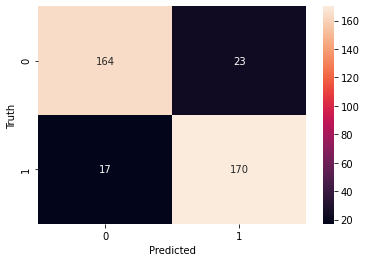

In [42]:
from matplotlib import pyplot as plt
import seaborn as sn
sn.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')

In [43]:
print(classification_report(y_test, y_predicted))

              precision    recall  f1-score   support

           0       0.91      0.88      0.89       187
           1       0.88      0.91      0.89       187

    accuracy                           0.89       374
   macro avg       0.89      0.89      0.89       374
weighted avg       0.89      0.89      0.89       374



In [44]:
reviews = [
    'Enter a chance to win $5000, hurry up, offer valid until march 31, 2021',
    'You are awarded a SiPix Digital Camera! call 09061221061 from landline. Delivery within 28days. T Cs Box177. M221BP. 2yr warranty. 150ppm. 16 . p pÂ£3.99',
    'it to 80488. Your 500 free text messages are valid until 31 December 2005.',
    'Hey Sam, Are you coming for a cricket game tomorrow',
    "Why don't you wait 'til at least wednesday to see if you get your ."
]
model.predict(reviews)

1/1 [==============================] - 2s 2s/step


array([[0.72683156],
       [0.8114108 ],
       [0.75923526],
       [0.19121873],
       [0.10543556]], dtype=float32)